# Mini-Project Solution: Character-Level Autoregressive Transformer in PyTorch

This notebook is a **complete working solution** for the mini-project:
**implement a character-level autoregressive Transformer for text generation**.

It includes:

1. loading a text corpus
2. character-level tokenization
3. training/validation split
4. mini-batch generation
5. masked multi-head self-attention
6. Transformer blocks
7. cross-entropy training
8. autoregressive generation with temperature

You can run it on CPU or GPU.

> **Recommended usage:** place a text file called `input.txt` in the same folder as this notebook.  
> If `input.txt` is not found, the notebook uses a small fallback corpus so that the code still runs.

This notebook was completed with the help of course materials available at https://mcapeltu.github.io/transformers_course_2026/ and is organised as follows:

1. Data utilities

--> load the text corpus

--> build chars, stoi, itos

--> define encode() and decode()

--> convert text into a tensor

--> split into training and validation sets

--> define get_batch()

2. Model components

--> define Config

--> implement Head

--> implement MultiHeadAttention

--> implement FeedForward

--> implement Block

--> implement CharTransformer

3. Training script

--> create the model

--> define estimate_loss()

--> create the optimizer

--> run the training loop

--> store or plot loss values

4. Generation script

--> choose a seed token or seed text

--> call model.generate(...)

--> decode generated token IDs back to text

--> inspect attention weights

In [1]:
import math
import os
import time
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F

print("PyTorch version:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

PyTorch version: 2.11.0
Device: cpu


## 1. Data utilities


In [2]:
# --> load the text corpus
## Objective: Load and prepare the text corpus for training.
## Reference: Given as a part of a mini project skeleton.

fallback_text = (
    "To be, or not to be, that is the question:\n"
    "Whether 'tis nobler in the mind to suffer\n"
    "The slings and arrows of outrageous fortune,\n"
    "Or to take arms against a sea of troubles\n"
    "And by opposing end them.\n"
) * 200

if os.path.exists("input.txt"):
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()
    source_name = "input.txt"
else:
    text = fallback_text
    source_name = "fallback_text"
    print("Fallback text used.")

print("Corpus source:", source_name)
print("Corpus length (characters):", len(text))
print()
print(text[:500])

Corpus source: input.txt
Corpus length (characters): 1115394

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
# Character vocabulary and tokenization
## Objective: Create character-level vocabulary and encoding/decoding functions.
## Reference: cours Mini-project workshop, slides 5-8.

# --> build chars, stoi, itos

# get the unique characters in the text
chars = sorted(list(set(text)))
vocab_size = len(chars)

# create dictionaries
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

# --> define encode() and decode()
def encode(s: str):
    return [stoi[c] for c in s]

def decode(indices):
    return "".join(itos[i] for i in indices)

# --> convert text into a tensor
data = torch.tensor(encode(text), dtype=torch.long)

# sanity check
print("Vocabulary size:", vocab_size)
print("First 65 vocabulary symbols:", chars[:65])
print("Encoded data shape:", data.shape)

Vocabulary size: 65
First 65 vocabulary symbols: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Encoded data shape: torch.Size([1115394])


In [4]:
# Train/validation split
## Objective: Split the dataset into training and validation sets for model evaluation.
## Reference: cours Mini-project workshop, slide 17.

# --> split into training and validation sets
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

# sanity check
print(len(train_data), len(val_data))

1003854 111540


In [5]:
# Batch generation
## Objective: Create batches of input and target sequences for training the model.
## Reference: cours Mini-project workshop, slide 19.

# --> define get_batch()
def get_batch(split):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - cfg.block_size - 1, (cfg.batch_size,))
    x = torch.stack([source[i:i + cfg.block_size] for i in ix])
    y = torch.stack([source[i + 1:i + cfg.block_size + 1] for i in ix])
    x, y = x.to(device), y.to(device) # move to device, to avoid missmatch (cours Mini-project workshop, slide 88)
    return x, y

## 2. Model components

### Transformer components:

In [6]:
# Configuration
# --> define Config
## Objective: Define configuration parameters for training and model architecture.
## Reference: cours Mini-project workshop, slide 14.

@dataclass
class Config:
    batch_size: int = 32     
    block_size: int = 64    
    learning_rate: float = 3e-4
    eval_iters: int = 200 
    n_embd: int = 128        
    n_head: int = 4           
    n_layer: int = 3         
    dropout: float = 0.1
    train_split: float = 0.9
    seed: int = 42
    generate_tokens: int = 300 

    max_iters: int = 23000
    eval_interval: int = 500
    eval_iters: int = 200

cfg = Config()
torch.manual_seed(cfg.seed)

# One masked self-attention head
# --> implement Head
## Objective: Implement the forward pass of a single attention head, including the causal mask.
## Reference: cours Mini-project workshop, slides 23-27.

class Head(nn.Module):
    def __init__(self, head_size: int):
        super().__init__()
        self.key = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.query = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.value = nn.Linear(cfg.n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(cfg.dropout)
        self.register_buffer(
            "tril",
            torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        )

    def forward(self, x, return_weights=False):

        B, T, C = x.shape
        # Step 1: project each token embedding into three new spaces (slide 24)
        k = self.key(x) #(B, T, head_size)
        q = self.query(x) #(B, T, head_size)
        v = self.value(x) #(B, T, head_size)

        # Step 2: compare queries and keys (slides 24, 25)
        scores = (q @ k.transpose(-2, -1)) / (k.shape[-1]**0.5) #(B, T, T)

        # Step 3: apply causal mask (slide 26)
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        
        # Step 4: softmax (slide 26)
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        
        # Step 5: weighted sum of values (slide 26)
        out = weights @ v #(B, T, head_size)

        # Logic for the return_weights branch (slide 34)
        if return_weights: 
            return out, weights
        return out
       
# Multiple heads in parallel
# --> implement MultiHeadAttention
## Objective: Implement the MultiHeadAttention module that combines multiple attention heads and projects the output back to the embedding dimension.
## Reference: cours Mini-project workshop, slides 31-34.

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads: int, head_size: int):
        super().__init__()
        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(num_heads)]
        )
        self.proj = nn.Linear(num_heads * head_size, cfg.n_embd)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x, return_weights=False):
        # The return_weights=True Branch (slide 34)
        if return_weights:
            outs = []
            weights = []
            for h in self.heads:
                out_h, wei_h = h(x, return_weights=True)
                outs.append(out_h)
                weights.append(wei_h)
            out = torch.cat(outs, dim=-1)
            out = self.dropout(self.proj(out))
            return out, torch.stack(weights, dim=0)

        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

# Feedforward network    
# --> implement FeedForward
# Objective: Implement the position-wise feedforward.
# Reference: cours Mini-project workshop, slide 41.
class FeedForward(nn.Module):
    def __init__(self, n_embd: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(cfg.dropout),
        )

    def forward(self, x):
        return self.net(x)


# Block of Transformer
# --> implement Block
# Objective: Implement a Transformer block that consists of multi-head attention followed by a feedforward network, with layer normalization and residual connections.
# Reference: cours Mini-project workshop, slides 37-43.
class Block(nn.Module):
    def __init__(self, n_embd: int, n_head: int):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x
    
# Full character-level autoregressive Transformer
# --> implement CharTransformer
## Objective: Implement the full character-level autoregressive Transformer model that includes token and positional embeddings, multiple Transformer blocks and a final linear layer to predict the next token.
## Reference: cours Mini-project workshop, slides 51-58.

class CharTransformer(nn.Module):

    # slide 51
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, cfg.n_embd)
        self.position_embedding_table = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks = nn.Sequential(
            *[Block(cfg.n_embd, cfg.n_head) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, vocab_size)
        self.apply(self._init_weights)

    # slide 52
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None: 
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    # slide 58
    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx) #(B,T,n_embd)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding_table(pos) #(T,n_embd)
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        # Computing the loss (slide 61)
        loss = None
        if targets is not None:
            B2, T2, C = logits.shape
            logits_flat = logits.view(B2 * T2, C)
            targets_flat = targets.view(B2 * T2)
            loss = F.cross_entropy(logits_flat, targets_flat)
        return logits, loss

    # slides 63, 64 67
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -cfg.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

    @torch.no_grad()
    def get_attention_weights(self, idx, block_number=0):
        self.eval()
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding_table(pos)
        x = tok_emb + pos_emb
        for i in range(block_number):
            x = self.blocks[i](x)  
        block = self.blocks[block_number]
        out, weights = block.sa(block.ln1(x), return_weights=True)
        return weights

# 3. TRAINING SCRIPT

In [ ]:
# --> create the model
## Objective: Instantiate the CharTransformer model and print its architecture and number of parameters.
## Reference: cours Mini-project workshop, slide 70.

model = CharTransformer().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(model)
print()
print(f"Number of parameters: {num_params:,}")

CharTransformer(
  (token_embedding_table): Embedding(65, 128)
  (position_embedding_table): Embedding(64, 128)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (ln1): LayerNorm((128,), eps=1e-05, elem

In [ ]:
# Loss estimation helper
# --> define estimate_loss()
## Objective: Implement a helper function to estimate the training and validation loss of the model.
## Reference: cours Mini-project workshop, slide 71.

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [9]:
# --> create the optimizer
## Objective: Set up the optimizer for training the model.
## Reference: cours Mini-project workshop, slide 73.
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=cfg.learning_rate
)

In [10]:
# --> Run the training loop
## Objective: Implement the training loop to train the model and periodically evaluate its performance on the training and validation sets.
## Reference: cours Mini-project workshop, slide 74 and slide 89.

train_losses = []
val_losses = []

start_time = time.time()
for iter in range(cfg.max_iters):
    if iter % cfg.eval_interval == 0 or iter == cfg.max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train']) #required for plotting
        val_losses.append(losses['val']) #required for plotting
        
        print(f"step {iter:4d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}")


    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f} seconds.")

step    0 | train loss 4.2156 | val loss 4.2126
step  500 | train loss 2.2294 | val loss 2.2487
step 1000 | train loss 1.9361 | val loss 2.0138
step 1500 | train loss 1.7792 | val loss 1.9106
step 2000 | train loss 1.6772 | val loss 1.8374
step 2500 | train loss 1.6245 | val loss 1.7928
step 3000 | train loss 1.5803 | val loss 1.7546
step 3500 | train loss 1.5497 | val loss 1.7248
step 4000 | train loss 1.5065 | val loss 1.6956
step 4500 | train loss 1.4851 | val loss 1.6726
step 5000 | train loss 1.4649 | val loss 1.6620
step 5500 | train loss 1.4521 | val loss 1.6291
step 6000 | train loss 1.4371 | val loss 1.6233
step 6500 | train loss 1.4205 | val loss 1.6185
step 7000 | train loss 1.4137 | val loss 1.6031
step 7500 | train loss 1.4063 | val loss 1.6003
step 8000 | train loss 1.3940 | val loss 1.5958
step 8500 | train loss 1.3855 | val loss 1.5866
step 9000 | train loss 1.3773 | val loss 1.5914
step 9500 | train loss 1.3724 | val loss 1.5832
step 10000 | train loss 1.3596 | val los

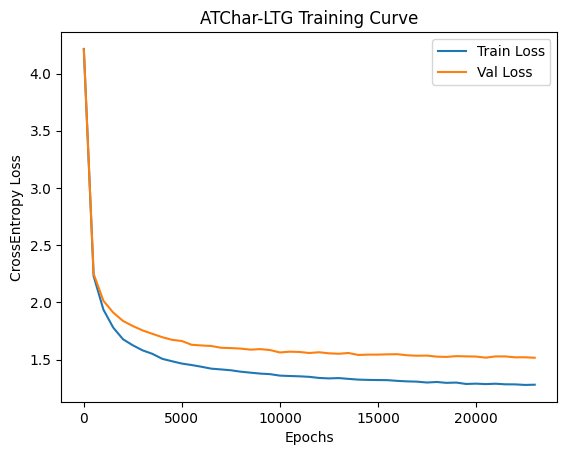

In [ ]:
# --> plot loss values
## Objective: Store the loss values during training and plot them to visualize the training progress.
## Reference: cours Mini-project workshop slides 74, 86.

import matplotlib.pyplot as plt

# Reconstruct the iteration points corresponding to the stored loss values
iterations = [i for i in range(cfg.max_iters) if i % cfg.eval_interval == 0 or i == cfg.max_iters - 1]

# Plotting Training Curve
plt.plot(iterations, train_losses, label='Train Loss')
plt.plot(iterations, val_losses, label='Val Loss')
plt.title("ATChar-LTG Training Curve")
plt.xlabel("Epochs")
plt.ylabel("CrossEntropy Loss")
plt.legend()
plt.show()

# 4. Generation script

In [ ]:
# Generating text
## Objective: Use the trained model to generate new text based on a seed token or seed text.
## Reference: cours Mini-project workshop, slide 77.


# EXAMPLE 1-BASELINE
# --> choose a seed token or seed text
seed = "good citizens"
context = torch.tensor([encode(seed)], 
                       dtype=torch.long, 
                       device=device)

# --> call model.generate(...)
generated = model.generate(
    context, 
    max_new_tokens=cfg.generate_tokens, 
    temperature=0.8)

# --> decode generated token IDs back to text
print("EXAMPLE 1:")
print(decode(generated[0].tolist()))



# EXAMPLE 2-LONGER SEED
# --> choose a seed token or seed text
seed = "Rather to die than to famish"
context = torch.tensor([encode(seed)], 
                       dtype=torch.long, 
                       device=device)

# --> call model.generate(...)
generated = model.generate(
    context, 
    max_new_tokens=cfg.generate_tokens, 
    temperature=0.8)

# --> decode generated token IDs back to text
print("\n\n\nEXAMPLE 2:")
print(decode(generated[0].tolist()))



# EXAMPLE 3-HIGHER TEMPERATURE
# --> choose a seed token or seed text
seed = "And by opposing"
context = torch.tensor([encode(seed)], 
                       dtype=torch.long, 
                       device=device)

# --> call model.generate(...)
generated = model.generate(
    context, 
    max_new_tokens=cfg.generate_tokens, 
    temperature=1.2)

# --> decode generated token IDs back to text
print("\n\n\nEXAMPLE 3:")
print(decode(generated[0].tolist()))

EXAMPLE 1:
good citizens,
And to cupbour deserve this cloudy loss
That seech thou now, myself well may prophecy
With me both where be not you not better king.

ROMEO:
I have the join'd of good to-morrow?

BRUTUS:
Say you in joy.

VOLUMNIA:
Thou wordst, noble traitor is a farther,
If I should be seen one for my daughter,
Wh



EXAMPLE 2:
Rather to die than to famish it is as well,
And not then they to-morrow.

DUKE VINCENTIO:
That shall be not talk, I may be too furthe death,
Upon the mile northumberland in heaven,
Nor such as is love, to prive the discover'd
And now with a littleman of face of fair:
Then shall I say the joy of your wife,
And as you ask it can



EXAMPLE 3:
And by opposing that I speak is common to thy fi,
For tle.

ELBOW:
Lretisly, sir, milk!

CLARENCE:
O, no; Give you out the gentle incest flutters,
As is contriolent and peace yoky,
An York father, be and losed hence, and all go,
And so birdly atthem, Scatle, I draw saint.

FRIAR LAURENCE:
All brazedr to so Richard


In [15]:
# Inspect a causal attention matrix
## Inspect attention weights and verify the causal masking behaviour.
## Reference: cours Mini-project workshop, slides 92, 93.

# --> inspect attention weights
sample_text = "good citizens"
sample_idx = torch.tensor(
    [encode(sample_text[:min(len(sample_text), cfg.block_size)])],
    dtype=torch.long, 
    device=device
)

weights = model.get_attention_weights(sample_idx, block_number=0)
print("Attention weights shape:", weights.shape)


# Verify the causal mask
first_head = weights[0, 0].detach().cpu()

print("\nFirst attention head matrix:")
print(first_head)

# check future tokens
print("\nUpper-triangular part (future attention) should be zero:")
print(torch.triu(first_head, diagonal=1))

Attention weights shape: torch.Size([4, 1, 13, 13])

First attention head matrix:
tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [9.4536e-01, 5.4636e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [4.8087e-01, 4.7365e-01, 4.5486e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [9.6180e-02, 2.3645e-01, 5.6023e-01, 1.0714e-01, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [8.7993e-03, 4.5828e-03, 9.9973e-02, 8.2107e-01, 6.5577e-02, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00]

Notes for use

- `block_size` is the maximum context length.
- `n_embd` is the token representation size.
- `n_head` is the number of attention heads.
- `n_layer` is the number of Transformer blocks.
- Causal masking is implemented inside each attention.
- Generation is **autoregressive**: one token is sampled and appended at a time.
- Training uses **teacher forcing** and **cross-entropy loss**.